In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import json
import glob
import random
import cv2
import time
import yaml
import torch
import shutil
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt

## * 아이디어성

* 혹시 성능이 잘 나오지 않는게, 파손 이미지 대미지별 종류 떄문일까? 그렇다면 -> 종류별로 모델을 따로 학습/추론?
  * 이거의 문제는 만약에 실추론시 4개의 모델을 모두 돌려야한다는 문제점 발생

## 0. 데이터 이해 및 사전 분석

### 0.0. 데이터 형식 확인

In [ ]:
# segmentation이니까 bbox만 사용

label_dir = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/(share)2026_ImageDetectionStudy_No_resizing/damaged/labels"

json_files = sorted([
    os.path.join(label_dir, f)
    for f in os.listdir(label_dir)
    if f.endswith(".json")
])

# n번째 json 읽기 (0,1,2,...)
idx = 0
with open(json_files[idx], "r", encoding="utf-8") as f:
    data = json.load(f)

# print(json_files[idx])
data

{'info': {'name': 'socar', 'date_created': '03/08/2022'},
 'images': {'id': 1,
  'width': 960,
  'height': 720,
  'file_name': '0000459_sc-226797.jpg'},
 'annotations': [{'id': 2,
   'image_id': 1,
   'category_id': 'sc-226797',
   'segmentation': [[[[3, 360],
      [342, 374],
      [548, 379],
      [746, 375],
      [960, 363],
      [946, 377],
      [865, 387],
      [734, 396],
      [710, 396],
      [480, 399],
      [226, 396],
      [58, 379],
      [5, 374],
      [3, 360]]]],
   'area': 19507.0,
   'bbox': [3, 360, 957, 39],
   'damage': 'Separated',
   'part': None,
   'year': 2018,
   'color': 'White',
   'level': None,
   'repair': []}],
 'categories': {'id': 'sc-226797', 'supercategory_name': 'Full-size car'}}

### 0.1. 기본 통계 확인
- 전체 데이터 규모 파악
- bbox 통계 분석
- 결론
  - 겸치는 정도 수치화(00에서 확인했던 문제점)
  - small object 문제 확인

In [ ]:
# ===========================
# 1. 경로 설정
# ===========================

IMAGE_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/(share)2026_ImageDetectionStudy_No_resizing/damaged/images"
LABEL_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/(share)2026_ImageDetectionStudy_No_resizing/damaged/labels"

json_files = glob.glob(os.path.join(LABEL_DIR, "*.json"))

print(f"총 JSON 파일 수: {len(json_files)}")

총 JSON 파일 수: 1201


In [ ]:
# ===========================
# 2. 기본 통계 저장용 변수
# ===========================

image_sizes = []              # (width, height)
bbox_counts = []              # 이미지당 bbox 개수
bbox_areas = []               # bbox 면적
bbox_area_ratios = []         # bbox 면적 비율 (image 대비)
image_union_area_ratios = []       # 🔥 이미지 단위 union 기준
overlap_count = 0             # IoU > 0.3 인 bbox 쌍 개수
total_bbox_pairs = 0          # 전체 bbox pair 개수

In [ ]:
# ===========================
# 3. IoU 계산 함수
# ===========================

def compute_iou(box1, box2):
    """
    box format: [x, y, w, h]
    """
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # 좌표 변환
    xa1, ya1 = x1, y1
    xa2, ya2 = x1 + w1, y1 + h1

    xb1, yb1 = x2, y2
    xb2, yb2 = x2 + w2, y2 + h2

    # 교집합 계산
    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = w1 * h1
    area_b = w2 * h2

    union_area = area_a + area_b - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area


In [ ]:
# ===========================
# 4. JSON 순회
# ===========================

for json_path in tqdm(json_files):

    with open(json_path, 'r') as f:
        data = json.load(f)

    width = data["images"]["width"]
    height = data["images"]["height"]
    image_area = width * height

    image_sizes.append((width, height))

    annotations = data.get("annotations", [])
    bbox_counts.append(len(annotations))

    boxes = []

    # 🔹 union 계산용 mask 생성
    union_mask = np.zeros((height, width), dtype=np.uint8)

    for ann in annotations:
        bbox = ann["bbox"]  # [x, y, w, h]
        boxes.append(bbox)

        x, y, w, h = map(int, bbox)

        # --- 1️⃣ bbox 개별 면적 통계 ---
        area = w * h
        bbox_areas.append(area)
        bbox_area_ratios.append(area / image_area)

        # --- 2️⃣ union mask에 채우기 ---
        union_mask[y:y+h, x:x+w] = 1

    # 🔥 union 기준 면적 계산 (겹친 픽셀 중복 제거)
    union_area = union_mask.sum()
    image_union_area_ratios.append(union_area / image_area)

    # --- 3️⃣ bbox 겹침 통계 ---
    for i in range(len(boxes)):
        for j in range(i+1, len(boxes)):
            total_bbox_pairs += 1
            iou = compute_iou(boxes[i], boxes[j])
            if iou > 0.3:
                overlap_count += 1

100%|██████████| 1201/1201 [01:08<00:00, 17.60it/s] 


In [ ]:
# ===========================
# 5. 결과 요약
# ===========================

image_sizes = np.array(image_sizes)
bbox_counts = np.array(bbox_counts)
bbox_areas = np.array(bbox_areas)
bbox_area_ratios = np.array(bbox_area_ratios)
image_union_area_ratios = np.array(image_union_area_ratios)

print("\n===== 데이터 통계 요약 =====")

print(f"총 이미지 수: {len(image_sizes)}")
print(f"평균 이미지 해상도: {image_sizes.mean(axis=0)}")
print(f"이미지당 평균 bbox 개수: {bbox_counts.mean():.2f}")

print(f"\n[개별 bbox 기준]")
print(f"bbox 평균 면적 (pixel): {bbox_areas.mean():.2f}")
print(f"bbox 평균 면적 비율: {bbox_area_ratios.mean():.4f}")

print(f"\n[이미지 union 기준]")
# 이미지 내 모든 bbox를 그냥 하나로 쳤을 때
print(f"이미지당 평균 union 면적 비율: {image_union_area_ratios.mean():.4f}")

if total_bbox_pairs > 0:
    print(f"IoU > 0.3 비율: {overlap_count / total_bbox_pairs:.4f}")
    # 모든 bbox pair 중 IoU가 0.3보다 큰 쌍의 비율
else:
    print("bbox pair 없음")


===== 데이터 통계 요약 =====
총 이미지 수: 1201
평균 이미지 해상도: [     999.54      983.04]
이미지당 평균 bbox 개수: 3.16

[개별 bbox 기준]
bbox 평균 면적 (pixel): 43412.42
bbox 평균 면적 비율: 0.0479

[이미지 union 기준]
이미지당 평균 union 면적 비율: 0.1334
IoU > 0.3 비율: 0.0201


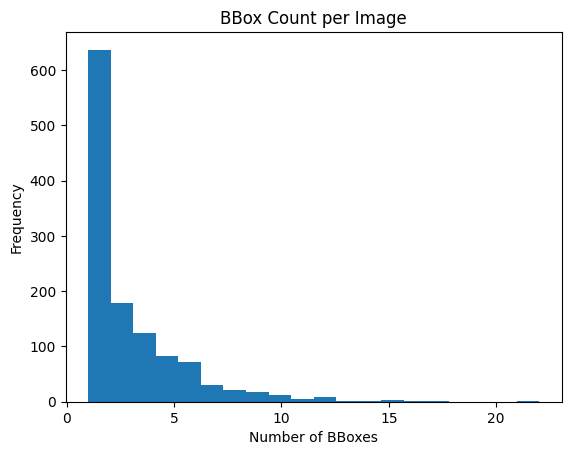

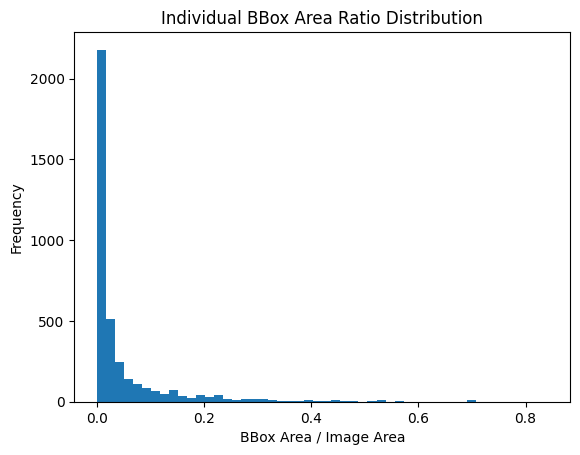

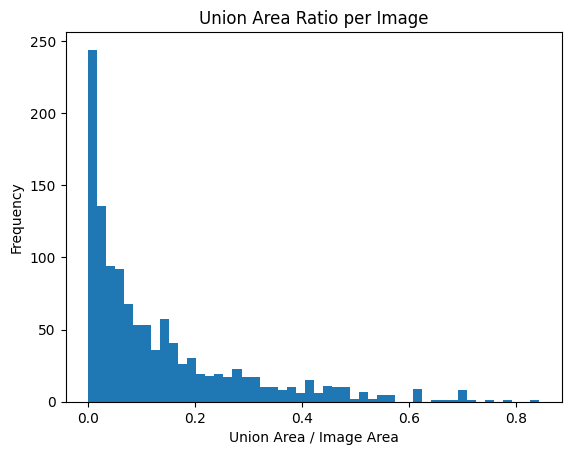

In [ ]:
# ===========================
# 6. 분포 시각화
# ===========================

plt.figure()
plt.hist(bbox_counts, bins=20)
plt.title("BBox Count per Image")
plt.xlabel("Number of BBoxes")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(bbox_area_ratios, bins=50)
plt.title("Individual BBox Area Ratio Distribution")
plt.xlabel("BBox Area / Image Area")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(image_union_area_ratios, bins=50)
plt.title("Union Area Ratio per Image")
plt.xlabel("Union Area / Image Area")
plt.ylabel("Frequency")
plt.show()

### 0.2. 랜덤 이미지 시각화
- 20장
- BBOX 및 파손 비율 등등 확인
- 데이터 전처리 등 전략 세우기 위함

In [ ]:
# ============================
# 1. 랜덤 20장 선택
# ============================

sample_files = random.sample(json_files, 20)

In [ ]:
# ============================
# 2. 시각화
# ============================

for json_path in sample_files:

    with open(json_path, 'r') as f:
        data = json.load(f)

    image_info = data["images"]
    width = image_info["width"]
    height = image_info["height"]
    file_name = image_info["file_name"]

    image_path = os.path.join(IMAGE_DIR, file_name)

    if not os.path.exists(image_path):
        continue

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    image_area = width * height
    annotations = data.get("annotations", [])

    boxes = []
    area_ratios = []

    for ann in annotations:
        bbox = ann["bbox"]  # [x,y,w,h]
        boxes.append(bbox)

        area = bbox[2] * bbox[3]
        area_ratios.append(area / image_area)

    # ============================
    # bbox 겹침 확인
    # ============================

    overlap_pairs = []

    for i in range(len(boxes)):
        for j in range(i+1, len(boxes)):
            iou = compute_iou(boxes[i], boxes[j])
            if iou > 0.3:
                overlap_pairs.append((i, j))

    # ============================
    # 시각화
    # ============================

    plt.figure(figsize=(6,6))
    plt.imshow(img)

    for idx, bbox in enumerate(boxes):
        x, y, w, h = bbox

        # 겹치는 bbox는 빨간색
        color = "red"
        for pair in overlap_pairs:
            if idx in pair:
                color = "yellow"

        rect = plt.Rectangle((x, y), w, h,
                             fill=False,
                             edgecolor=color,
                             linewidth=2)
        plt.gca().add_patch(rect)

        plt.text(x, y-5,
                 f"{area_ratios[idx]:.3f}",
                 color=color,
                 fontsize=8,
                 backgroundcolor="black")

    # 밝기 평균
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    brightness = np.mean(gray)

    plt.title(f"{file_name}\n"
              f"bbox: {len(boxes)} | "
              f"overlap_pairs: {len(overlap_pairs)} | "
              f"brightness: {brightness:.1f}")

    plt.axis("off")
    plt.show()

* 인사이트
  * 너무 작은 파손 부위 존재
  * 이 경우 대체로 차량 사진이 너무 멀리서 찍힘... -> 그래서 crop하면 해결될 것으로 예상된다..!
  * 생각보다 bbox끼리 겹치는 경우는 많지 않음

### 0.3. 데이터 분할 전략

* 아래에서 다시해서 여기서 필요 없음

- train/val/test split
- 동일 차량 ID 중복 방지
  - id가 동일한 차량의 경우 같은 set에 들어가야함 (data leakage 방지)
- Stage 2 모델 학습용 데이터셋

In [ ]:
# ==============================
# 1. 경로 설정
# ==============================

BASE_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/(share)2026_ImageDetectionStudy_No_resizing/damaged"

IMAGE_DIR = os.path.join(BASE_DIR, "images")
LABEL_DIR = os.path.join(BASE_DIR, "labels")

OUTPUT_DIR = os.path.join(BASE_DIR, "yolo_dataset")

SPLIT_RATIO = (0.7, 0.15, 0.15)  # train, val, test

random.seed(42)

In [ ]:
# ==============================
# 2. vehicle_id 기준 그룹화
# ==============================

json_files = glob.glob(os.path.join(LABEL_DIR, "*.json"))

vehicle_groups = defaultdict(list)
json_file_cnt = 0

for json_path in json_files:
    json_file_cnt += 1

    with open(json_path, 'r') as f:
        data = json.load(f)

    vehicle_id = data["annotations"][0]["category_id"]
    vehicle_groups[vehicle_id].append(json_path)

print(f"총 차량 ID 수: {len(vehicle_groups)}")
print(f"총 차량 개수: {json_file_cnt}")

# 실제로 1201개의 차량 이미지 중 일부는 중복...!

총 차량 ID 수: 1063
총 차량 개수: 1201


In [ ]:
# ==============================
# 3. vehicle_id 기준 중복 시각화
# ==============================

# 중복 vehicle_id 필터링
duplicate_groups = {vid: paths for vid, paths in vehicle_groups.items() if len(paths) > 1}

print(f"\n중복 vehicle_id 개수: {len(duplicate_groups)}")

total_duplicate_images = sum(len(v) for v in duplicate_groups.values())
print(f"중복에 해당하는 전체 이미지 수: {total_duplicate_images}")

# 랜덤으로 일부 ID 시각화
sample_ids = random.sample(list(duplicate_groups.keys()),
                           min(10, len(duplicate_groups)))

print("\n시각화할 vehicle_id:", sample_ids)

for vid in sample_ids:

    json_list = duplicate_groups[vid]

    plt.figure(figsize=(15,5))

    for i, json_path in enumerate(json_list):

        with open(json_path, 'r') as f:
            data = json.load(f)

        img_info = data["images"]
        file_name = img_info["file_name"]

        img_path = os.path.join(IMAGE_DIR, file_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # bbox 시각화
        for ann in data.get("annotations", []):
            x, y, w, h = ann["bbox"]
            cv2.rectangle(img,
                          (int(x), int(y)),
                          (int(x+w), int(y+h)),
                          (255,0,0),
                          2)

        plt.subplot(1, len(json_list), i+1)
        plt.imshow(img)
        plt.title(file_name)
        plt.axis("off")

    plt.suptitle(f"Vehicle ID: {vid}", fontsize=14)
    plt.show()

In [ ]:
# ==============================
# 4. Group Split
# ==============================

# 앞에서 볼 수 있듯이 동일한 차량인데 사진을 찍은 방향이 다른 경우 존재하기에 group split 필수

vehicle_ids = list(vehicle_groups.keys())
random.shuffle(vehicle_ids)

n_total = len(vehicle_ids)
n_train = int(n_total * SPLIT_RATIO[0])
n_val = int(n_total * SPLIT_RATIO[1])

train_ids = vehicle_ids[:n_train]
val_ids = vehicle_ids[n_train:n_train+n_val]
test_ids = vehicle_ids[n_train+n_val:]

print("Train IDs:", len(train_ids))
print("Val IDs:", len(val_ids))
print("Test IDs:", len(test_ids))

Train IDs: 744
Val IDs: 159
Test IDs: 160


In [ ]:
# ==============================
# 5. YOLO 폴더 구조 생성
# ==============================

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, "images", split), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "labels", split), exist_ok=True)

In [ ]:
# ==============================
# 6. YOLO format 변환 함수
# ==============================

def convert_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox

    x_center = (x + w/2) / img_w
    y_center = (y + h/2) / img_h
    w /= img_w
    h /= img_h

    return x_center, y_center, w, h

In [ ]:
# ==============================
# 7. 파일 복사 + label 변환
# ==============================

# 차량단위의 split은 유지하면서 YOLO 포맷으로 train/val/test split

def process_split(id_list, split_name):

    for vid in tqdm(id_list):
        json_list = vehicle_groups[vid]

        for json_path in json_list:
            with open(json_path, 'r') as f:
                data = json.load(f)

            img_info = data["images"]
            file_name = img_info["file_name"]
            img_w = img_info["width"]
            img_h = img_info["height"]

            src_img_path = os.path.join(IMAGE_DIR, file_name)
            dst_img_path = os.path.join(OUTPUT_DIR, "images", split_name, file_name)

            # 이미지 복사
            shutil.copy(src_img_path, dst_img_path)

            # YOLO label 생성
            label_lines = []
            for ann in data.get("annotations", []):
                bbox = ann["bbox"]
                x_c, y_c, w, h = convert_to_yolo(bbox, img_w, img_h)

                class_id = 0  # 파손 하나만 클래스라고 가정
                label_lines.append(f"{class_id} {x_c} {y_c} {w} {h}")

            label_file = file_name.replace(".jpg", ".txt")
            label_path = os.path.join(OUTPUT_DIR, "labels", split_name, label_file)

            with open(label_path, "w") as f:
                f.write("\n".join(label_lines))

# 실행
process_split(train_ids, "train")
process_split(val_ids, "val")
process_split(test_ids, "test")

100%|██████████| 160/160 [02:31<00:00,  1.05it/s]


In [ ]:
# ==============================
# 8. data.yaml 생성
# ==============================

yaml_content = f"""
path: {OUTPUT_DIR}
train: images/train
val: images/val
test: images/test

nc: 1
names: ['damage']
"""

with open(os.path.join(OUTPUT_DIR, "data.yaml"), "w") as f:
    f.write(yaml_content)

print("\n✅ Dataset Split 완료 (Leakage 방지 적용)")


✅ Dataset Split 완료 (Leakage 방지 적용)


## 1. Stage 1 : 차량 object detection

- 일단 학습 데이터셋이 없다
- COCO pretrained로 가보쟈

- 확인 사항
  1. vehicle miss rate : 차량 탐지 못한 이미지 수
  2. bbox가 너무 크게 잡히는지
  3. 복수차량 있을 때 처리
  4. conf threshold 조정



### 1.1. pretrained model inference
* COCO dataset으로 pretrained된 모델로 차량 bbox inference

* COCO dataset
  * 80개의 class
  * bbox detection 기준 학습
  * 결과 라벨 : 2(car), 3(motorcycle), 5(bus), 7(truck)

In [ ]:
# ==============================
# 1. 모델 로드 (COCO pretrained)
# ==============================

!pip install ultralytics
from ultralytics import YOLO

model = YOLO("yolov8m.pt")  # COCO pretrained model

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ==============================
# 2. 이미지 경로 설정
# ==============================

DAMAGED_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/(share)2026_ImageDetectionStudy_No_resizing/damaged/images"
NORMAL_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/(share)2026_ImageDetectionStudy_No_resizing/normal/images"

damaged_paths = glob.glob(os.path.join(DAMAGED_DIR, "*.jpg"))
normal_paths = glob.glob(os.path.join(NORMAL_DIR, "*.jpg"))

# dataset label 포함
image_dataset = []

for p in damaged_paths:
    image_dataset.append((p, "damaged"))

for p in normal_paths:
    image_dataset.append((p, "normal"))

print("Damaged:", len(damaged_paths))
print("Normal:", len(normal_paths))
print("Total:", len(image_dataset))

# inference용 path만 추출
image_paths = [p[0] for p in image_dataset]

Damaged: 1200
Normal: 157
Total: 1357


In [ ]:
# ==============================
# 3. Inference 실행 (vehicle만)
# ==============================

vehicle_classes = [2, 3, 5, 7]

count = 0

for img_path in image_paths:

    for r in model.predict(
        source=img_path,
        conf=0.2,
        imgsz=640,
        classes=vehicle_classes,
        device=0,
        save=True,
        save_txt=True,
        project="/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference",
        name="yolov8m_vehicle_detection",
        exist_ok=True,
        verbose=False
    ):
        count += 1

print("✅ Inference 완료")
print("총 결과 개수:", count)

Results saved to /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection
0 label saved to /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection/labels
Results saved to /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection
1 label saved to /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection/labels
Results saved to /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection
1 label saved to /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection/labels
Results saved to /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection
2 labels saved to /content/drive/MyDrive/hdmf-ai-auto-s

### 1.2. pretrained model 정성평가
1. miss rate 측정
  * 차량 있는데 detection 못한 이미지 수 파악
  * 현재에는 모든 차량에 이미지가 있기 때문..!
    * <5% → 매우 우수
    * 5~10% → borderline
    * 10% → fine-tune 필요
2. bbox 적절성
  * 차량 전체를 잘 포함하는가?
  * 너무 타이트해서 잘리는가? (padding해서 crop)
  * 너무 커서 배경이 많이 들어가 있는가?
  * 각도 심한 차량 잘 잡는가?
  * bbox_area / image_area 분포 확인
3. random detection 시각화

In [ ]:
# ==============================
# 1. miss rate 측정
# ==============================
# 모든 이미지에 차량이 있다고 가정, 차량을 찾지 못한 비율 계산

RESULT_LABEL_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection/labels"

records = []

for img_path, dataset_type in image_dataset:

    file_name = os.path.basename(img_path).replace(".jpg", ".txt")
    label_path = os.path.join(RESULT_LABEL_DIR, file_name)

    detected = os.path.exists(label_path) and os.path.getsize(label_path) > 0

    records.append({
        "image": img_path,
        "dataset": dataset_type,
        "detected": detected
    })

df = pd.DataFrame(records)
summary = df.groupby("dataset")["detected"].agg(["count","sum"])
summary["miss"] = summary["count"] - summary["sum"]
summary["miss_rate"] = summary["miss"] / summary["count"]

print(summary)

print("\n전체 miss rate:", (df["detected"]==False).mean())

         count  sum  miss  miss_rate
dataset                             
damaged   1200  922   278   0.231667
normal     157  154     3   0.019108

전체 miss rate: 0.20707442888725128


In [ ]:
# ==============================
# 2.1. BBox Area Ratio 계산
# ==============================
# bbox 면적과 이미지 크기 비율 계산

import cv2
import pandas as pd

areas = []

for img_path, dataset_type in image_dataset:

    file_name = os.path.basename(img_path).replace(".jpg", ".txt")
    label_path = os.path.join(RESULT_LABEL_DIR, file_name)

    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    img_area = h * w

    with open(label_path) as f:
        lines = f.readlines()

    for line in lines:

        cls, xc, yc, bw, bh = map(float, line.split())

        bbox_area = (bw * w) * (bh * h)

        areas.append({
            "dataset": dataset_type,
            "ratio": bbox_area / img_area
        })

area_df = pd.DataFrame(areas)

print(area_df.groupby("dataset")["ratio"].describe())

          count      mean       std       min       25%       50%       75%  \
dataset                                                                       
damaged  1579.0  0.480547  0.346728  0.000213  0.046399  0.592744  0.756370   
normal    889.0  0.072085  0.148886  0.000241  0.003543  0.014061  0.065716   

              max  
dataset            
damaged  0.990475  
normal   0.986822  


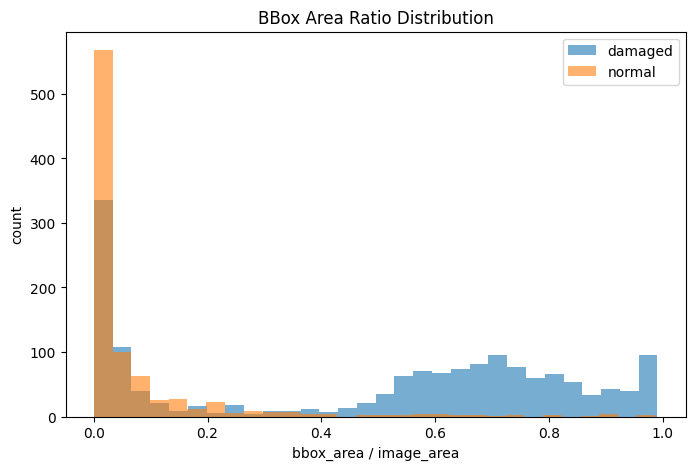

In [ ]:
# ==============================
# 2.2. Ratio Distribution
# ==============================

import matplotlib.pyplot as plt

damaged_ratios = area_df[area_df["dataset"]=="damaged"]["ratio"]
normal_ratios = area_df[area_df["dataset"]=="normal"]["ratio"]

plt.figure(figsize=(8,5))

plt.hist(damaged_ratios, bins=30, alpha=0.6, label="damaged")
plt.hist(normal_ratios, bins=30, alpha=0.6, label="normal")

plt.xlabel("bbox_area / image_area")
plt.ylabel("count")
plt.legend()

plt.title("BBox Area Ratio Distribution")

plt.show()

In [ ]:
# ==============================
# 3. Random Detection Visualization
# ==============================

import random
import matplotlib.pyplot as plt
import cv2

sample_images = random.sample(image_dataset, 20)

for img_path, dataset_type in sample_images:

    file_name = os.path.basename(img_path).replace(".jpg", ".txt")
    label_path = os.path.join(RESULT_LABEL_DIR, file_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if os.path.exists(label_path):

        with open(label_path) as f:
            lines = f.readlines()

        h, w = img.shape[:2]

        for line in lines:

            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)

    plt.figure(figsize=(5,5))
    plt.title(dataset_type)
    plt.imshow(img)
    plt.axis("off")

In [ ]:
# ==============================
# 4. Random Detection Visualization
# ==============================
# 이번에는 차량 인식하지 못한 데이터들.. 중심으로

damaged_miss_images = []

for img_path, dataset_type in image_dataset:

    if dataset_type != "damaged":
        continue

    file_name = os.path.basename(img_path).replace(".jpg", ".txt")
    label_path = os.path.join(RESULT_LABEL_DIR, file_name)

    detected = os.path.exists(label_path) and os.path.getsize(label_path) > 0

    if not detected:
        damaged_miss_images.append(img_path)

print("Damaged miss images:", len(damaged_miss_images))

sample_miss = random.sample(damaged_miss_images, min(20, len(damaged_miss_images)))

for img_path in sample_miss:

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.title("MISS - damaged")
    plt.imshow(img)
    plt.axis("off")

### 인사이트
  - 정상 이미지의 99%를 차량으로 인식
  - 파손 이미지의 77%를 차량으로 인식
    - 확인해보니, 인식하지 못한 이미지의 경우 사진이 너무 가까이서 찍혀서 인식 못함

- 결론
  - 파손 이미지의 23%는 crop없이 그대로 사용
  - 나머지 이미지는 stage1 데이터의 bbox를 기준으로 crop하여 stage 2의 파손 부위 탐지에 활용

## 2. Stage 2 : 차량 damage detection

### 2.1. 차량 이미지 crop

1. crop한 이미지 데이터셋 생성

    - stage1에서 차량 bbox 인식한 경우, crop / 인식하지 못한 경우, 그대로 사용
    - bbox 가장자리에 20% 정도 padding 줘서 crop
    - bbox 가 여러개인 경우 가장 크기가 큰 bbox 중심으로 crop
    - normal/damaged 폴더 분리해서 저장
    - damage bbox가 crop 때문에 잘리는 경우
      - Crop 진행 X

2. damage bbox annotation 위치 변환


In [ ]:
# ==============================
# 1. YOLO bbox -> pixel bbox
# ==============================

def yolo_to_pixel_bbox(txt_path, img_w, img_h):

    boxes = []

    if not os.path.exists(txt_path):
        return boxes

    with open(txt_path) as f:
        for line in f:

            cls, cx, cy, w, h = map(float, line.split())

            x1 = (cx - w/2) * img_w
            y1 = (cy - h/2) * img_h
            x2 = (cx + w/2) * img_w
            y2 = (cy + h/2) * img_h

            boxes.append([x1,y1,x2,y2])

    return boxes

In [ ]:
# ==============================
# 2. 가장 큰 bbox 선택
# ==============================

def select_largest_bbox(boxes):

    if len(boxes) == 0:
        return None

    areas = [(b[2]-b[0])*(b[3]-b[1]) for b in boxes]
    idx = np.argmax(areas)

    return boxes[idx]

In [ ]:
# ==============================
# 3. padding 적용
# ==============================

def apply_padding(bbox, img_w, img_h, pad_ratio=0.2):

    x1,y1,x2,y2 = bbox

    pad_w = (x2-x1)*pad_ratio
    pad_h = (y2-y1)*pad_ratio

    crop_x1 = max(0, int(x1-pad_w))
    crop_y1 = max(0, int(y1-pad_h))
    crop_x2 = min(img_w, int(x2+pad_w))
    crop_y2 = min(img_h, int(y2+pad_h))

    return crop_x1, crop_y1, crop_x2, crop_y2

In [ ]:
# ==============================
# 4. damage bbox crop 포함 여부 확인
# ==============================

def damage_inside_crop(anns, crop_bbox):

    cx1,cy1,cx2,cy2 = crop_bbox

    for ann in anns:

        x,y,w,h = ann["bbox"]

        x2 = x+w
        y2 = y+h

        if x < cx1 or y < cy1 or x2 > cx2 or y2 > cy2:
            return False

    return True

In [ ]:
# ==============================
# 5. damage bbox 좌표 변환
# ==============================

def convert_bbox_to_yolo(anns, crop_bbox, crop_w, crop_h):

    cx1,cy1,_,_ = crop_bbox

    labels = []

    for ann in anns:

        x,y,w,h = ann["bbox"]

        x2 = x+w
        y2 = y+h

        nx1 = x - cx1
        ny1 = y - cy1
        nx2 = x2 - cx1
        ny2 = y2 - cy1

        bw = nx2-nx1
        bh = ny2-ny1

        cx = (nx1 + bw/2) / crop_w
        cy = (ny1 + bh/2) / crop_h
        bw = bw / crop_w
        bh = bh / crop_h

        labels.append([0,cx,cy,bw,bh])

    return labels


In [ ]:
# ==============================
# 6. 메인 파이프라인
# ==============================

def create_crop_dataset(
    image_dataset,
    vehicle_bbox_dir,
    annotation_dir,
    output_dir
):

    os.makedirs(f"{output_dir}/damaged/images", exist_ok=True)
    os.makedirs(f"{output_dir}/damaged/labels", exist_ok=True)

    os.makedirs(f"{output_dir}/normal/images", exist_ok=True)
    os.makedirs(f"{output_dir}/normal/labels", exist_ok=True)


    for img_path, dataset_type in image_dataset:

        img_name = os.path.basename(img_path)

        img = cv2.imread(img_path)
        h,w = img.shape[:2]

        # ======================
        # damage annotation 읽기
        # ======================

        anns = []

        if dataset_type == "damaged":

            json_path = os.path.join(
                annotation_dir,
                img_name.replace(".jpg",".json")
            )

            if os.path.exists(json_path):

                with open(json_path) as f:
                    data = json.load(f)

                anns = data["annotations"]


        # ======================
        # vehicle bbox
        # ======================

        txt_path = os.path.join(
            vehicle_bbox_dir,
            img_name.replace(".jpg",".txt")
        )

        boxes = yolo_to_pixel_bbox(txt_path,w,h)

        crop_bbox = (0,0,w,h)

        largest_box = select_largest_bbox(boxes)

        if largest_box is not None:

            padded = apply_padding(largest_box,w,h)

            if damage_inside_crop(anns,padded):
                crop_bbox = padded


        x1,y1,x2,y2 = crop_bbox

        crop = img[y1:y2,x1:x2]

        crop_h,crop_w = crop.shape[:2]


        # ======================
        # bbox 좌표 변환
        # ======================

        labels = convert_bbox_to_yolo(anns,crop_bbox,crop_w,crop_h)


        save_type = "damaged" if len(labels)>0 else "normal"


        save_img = f"{output_dir}/{save_type}/images/{img_name}"
        save_lbl = f"{output_dir}/{save_type}/labels/{img_name.replace('.jpg','.txt')}"


        cv2.imwrite(save_img,crop)


        with open(save_lbl,"w") as f:
            for l in labels:
                f.write(" ".join(map(str,l))+"\n")

In [ ]:
# ==============================
# 7. 경로 설정
# ==============================

VEHICLE_BBOX_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage1_pretrained_inference/yolov8m_vehicle_detection/labels"

ANNOTATION_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/(share)2026_ImageDetectionStudy_No_resizing/damaged/labels"

OUTPUT_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_crop_dataset"

create_crop_dataset(
    image_dataset=image_dataset,
    vehicle_bbox_dir=VEHICLE_BBOX_DIR,
    annotation_dir=ANNOTATION_DIR,
    output_dir=OUTPUT_DIR
)

In [ ]:
# ==============================
# 8. 시각화 통해 기존 이미지 vs crop된 이미지 파악
# ==============================

NUM_SAMPLES = 20

crop_dataset_dir = OUTPUT_DIR

damaged_imgs = os.listdir(f"{crop_dataset_dir}/damaged/images")
normal_imgs = os.listdir(f"{crop_dataset_dir}/normal/images")

all_imgs = [(i,"damaged") for i in damaged_imgs] + [(i,"normal") for i in normal_imgs]

samples = random.sample(all_imgs, NUM_SAMPLES)


for img_name, dtype in samples:

    # ======================
    # 경로
    # ======================

    crop_img_path = f"{crop_dataset_dir}/{dtype}/images/{img_name}"
    crop_lbl_path = f"{crop_dataset_dir}/{dtype}/labels/{img_name.replace('.jpg','.txt')}"
    vehicle_lbl_path = f"{VEHICLE_BBOX_DIR}/{img_name.replace('.jpg','.txt')}"

    # 원본 이미지 찾기
    orig_img_path = None
    for p,l in image_dataset:
        if os.path.basename(p) == img_name:
            orig_img_path = p
            break


    # ======================
    # 이미지 로드
    # ======================

    orig = cv2.imread(orig_img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

    crop = cv2.imread(crop_img_path)
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

    h,w = orig.shape[:2]


    # ======================
    # 원본에 차량 bbox 그리기
    # ======================

    if os.path.exists(vehicle_lbl_path):

        with open(vehicle_lbl_path) as f:
            lines = f.readlines()

        for line in lines:

            cls,cx,cy,bw,bh = map(float,line.split())

            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)

            cv2.rectangle(
                orig,
                (x1,y1),
                (x2,y2),
                (0,255,0),
                3
            )


    # ======================
    # crop에 damage bbox
    # ======================

    if os.path.exists(crop_lbl_path):

        with open(crop_lbl_path) as f:
            lines = f.readlines()

        ch,cw = crop.shape[:2]

        for line in lines:

            cls,cx,cy,bw,bh = map(float,line.split())

            x1 = int((cx - bw/2) * cw)
            y1 = int((cy - bh/2) * ch)
            x2 = int((cx + bw/2) * cw)
            y2 = int((cy + bh/2) * ch)

            cv2.rectangle(
                crop,
                (x1,y1),
                (x2,y2),
                (255,0,0),
                3
            )


    # ======================
    # 시각화
    # ======================

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(orig)
    plt.title("Original + Vehicle BBox")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(crop)
    plt.title(f"Crop + Damage BBox ({dtype})")
    plt.axis("off")

    plt.show()


### 2.2. Dataset split
  * 1️⃣ crop된 dataset 기준으로 split (damaged + normal)
  * 2️⃣ vehicle ID 기준 split
  * 3️⃣ 동일 vehicle → 동일 set (train/val/test)
  * 4️⃣ 비율: 70 / 15 / 15
  * 5️⃣ YOLO dataset 구조로 이동

In [ ]:
# ===============================
# 1. 경로 설정
# ===============================

CROP_DATASET_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_crop_dataset"
SPLIT_DATASET_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

In [ ]:
# ===============================
# 2. 모든 이미지 수집
# ===============================

damaged_imgs = os.listdir(f"{CROP_DATASET_DIR}/damaged/images")
normal_imgs = os.listdir(f"{CROP_DATASET_DIR}/normal/images")

all_imgs = [(img,"damaged") for img in damaged_imgs] + [(img,"normal") for img in normal_imgs]


In [ ]:
# ===============================
# 3. vehicle ID 추출
# ===============================

def extract_vehicle_id(filename):

    # 0000459_sc-226797.jpg
    base = os.path.basename(filename)

    name = base.split(".")[0]

    vehicle_id = name.split("_")[1]

    return vehicle_id

In [ ]:
# ===============================
# 4. vehicle 기준 그룹화
# ===============================

vehicle_groups = defaultdict(list)

for img_name, dtype in all_imgs:

    vid = extract_vehicle_id(img_name)

    vehicle_groups[vid].append((img_name,dtype))


vehicle_ids = list(vehicle_groups.keys())

print("Total vehicle IDs:", len(vehicle_ids))

Total vehicle IDs: 1220


In [ ]:
# ===============================
# 5. vehicle 단위 shuffle
# ===============================

random.seed(42)
random.shuffle(vehicle_ids)

n_total = len(vehicle_ids)

train_end = int(n_total * TRAIN_RATIO)
val_end = int(n_total * (TRAIN_RATIO + VAL_RATIO))


train_ids = vehicle_ids[:train_end]
val_ids = vehicle_ids[train_end:val_end]
test_ids = vehicle_ids[val_end:]


print("Train vehicles:", len(train_ids))
print("Val vehicles:", len(val_ids))
print("Test vehicles:", len(test_ids))



Train vehicles: 854
Val vehicles: 183
Test vehicles: 183


In [ ]:
# ===============================
# 6. 폴더 생성
# ===============================

for split in ["train","val","test"]:

    os.makedirs(f"{SPLIT_DATASET_DIR}/{split}/images",exist_ok=True)
    os.makedirs(f"{SPLIT_DATASET_DIR}/{split}/labels",exist_ok=True)

In [ ]:
# ===============================
# 7. 파일 이동
# ===============================

def copy_split(vehicle_id_list, split):

    for vid in vehicle_id_list:

        for img_name, dtype in vehicle_groups[vid]:

            src_img = f"{CROP_DATASET_DIR}/{dtype}/images/{img_name}"
            src_lbl = f"{CROP_DATASET_DIR}/{dtype}/labels/{img_name.replace('.jpg','.txt')}"

            dst_img = f"{SPLIT_DATASET_DIR}/{split}/images/{img_name}"
            dst_lbl = f"{SPLIT_DATASET_DIR}/{split}/labels/{img_name.replace('.jpg','.txt')}"

            shutil.copy(src_img,dst_img)

            if os.path.exists(src_lbl):
                shutil.copy(src_lbl,dst_lbl)
            else:
                open(dst_lbl,"w").close()


copy_split(train_ids,"train")
copy_split(val_ids,"val")
copy_split(test_ids,"test")

print("✅ Vehicle ID 기반 dataset split 완료")

✅ Vehicle ID 기반 dataset split 완료


In [ ]:
print("train images:", len(os.listdir(f"{SPLIT_DATASET_DIR}/train/images")))
print("val images:", len(os.listdir(f"{SPLIT_DATASET_DIR}/val/images")))
print("test images:", len(os.listdir(f"{SPLIT_DATASET_DIR}/test/images")))

train images: 951
val images: 201
test images: 205


### 2.3. YOLO dataset format 정리



In [ ]:
dataset_root = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset"

splits = ["train", "val", "test"]

REMOVE_TINY_BOX = True
TINY_THRESHOLD = 0.003


def clamp(x):
    return max(0.0, min(1.0, x))

In [ ]:
# ===============================
# 1. label 없는 경우 처리
# ===============================

def ensure_label_exists(label_path):

    if not label_path.exists():
        label_path.touch()
        return True

    return False


In [ ]:
# ===============================
# 2. bbox 정리 (clamp + tiny box 제거)
# ===============================

def process_label_lines(lines):

    new_lines = []

    for line in lines:

        parts = line.strip().split()

        if len(parts) != 5:
            continue

        cls, cx, cy, w, h = parts
        cx, cy, w, h = map(float, [cx, cy, w, h])

        # bbox 범위 clamp
        cx = clamp(cx)
        cy = clamp(cy)
        w = clamp(w)
        h = clamp(h)

        # tiny bbox 제거
        if REMOVE_TINY_BOX:
            if w < TINY_THRESHOLD or h < TINY_THRESHOLD:
                continue

        new_lines.append(f"{cls} {cx} {cy} {w} {h}\n")

    return new_lines

In [ ]:
# ===============================
# 3. dataset split 순회
# ===============================
for split in splits:

    img_dir = Path(dataset_root) / split / "images"
    label_dir = Path(dataset_root) / split / "labels"

    images = list(img_dir.glob("*"))

    print(f"\nProcessing {split} ({len(images)} images)")

    for img_path in images:

        label_path = label_dir / (img_path.stem + ".txt")

        # ===============================
        # 3-1. label 없는 경우 처리
        # ===============================
        created = ensure_label_exists(label_path)
        if created:
            continue

        # ===============================
        # 3-2. label 읽기
        # ===============================
        with open(label_path, "r") as f:
            lines = f.readlines()

        # ===============================
        # 3-3. bbox 정리
        # ===============================
        new_lines = process_label_lines(lines)

        # ===============================
        # 3-4. label 다시 저장
        # ===============================
        with open(label_path, "w") as f:
            f.writelines(new_lines)


print("\nYOLO dataset format check 완료")


Processing train (951 images)

Processing val (201 images)

Processing test (205 images)

YOLO dataset format check 완료


In [ ]:
# ===============================
# 4. YOLO 포맷 점검
# ===============================

dataset_root = Path("/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset")

splits = ["train", "val", "test"]

error_count = 0


# ===============================
# 1. label format 검사
# ===============================
def check_label_file(label_path):

    global error_count

    with open(label_path, "r") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):

        parts = line.strip().split()

        # 1️⃣ 항목 개수 검사
        if len(parts) != 5:
            print(f"[FORMAT ERROR] {label_path} line {i+1}")
            error_count += 1
            continue

        cls, cx, cy, w, h = parts

        try:
            cls = int(cls)
            cx, cy, w, h = map(float, [cx, cy, w, h])
        except:
            print(f"[TYPE ERROR] {label_path} line {i+1}")
            error_count += 1
            continue

        # 2️⃣ 좌표 범위 검사
        if not (0 <= cx <= 1 and 0 <= cy <= 1 and 0 <= w <= 1 and 0 <= h <= 1):
            print(f"[RANGE ERROR] {label_path} line {i+1}")
            error_count += 1

        # 3️⃣ bbox 크기 검사
        if w <= 0 or h <= 0:
            print(f"[SIZE ERROR] {label_path} line {i+1}")
            error_count += 1


# ===============================
# 2. dataset 전체 검사
# ===============================
for split in splits:

    label_dir = dataset_root / split / "labels"
    label_files = list(label_dir.glob("*.txt"))

    print(f"\nChecking {split} ({len(label_files)} labels)")

    for label_path in label_files:
        check_label_file(label_path)


# ===============================
# 3. 결과 출력
# ===============================
if error_count == 0:
    print("\n✅ 모든 label이 YOLO format에 맞습니다.")
else:
    print(f"\n❌ 총 {error_count}개의 label 문제가 발견되었습니다.")


Checking train (951 labels)

Checking val (201 labels)

Checking test (205 labels)

✅ 모든 label이 YOLO format에 맞습니다.


### 2.4. YOLOv8 Baseline

* ├── experiments
* │   │
* │   ├── yolov8n_baseline
* │   │   ├── weights
* │   │   │   └── best.pt
* │   │   │
* │   │   ├── predictions
* │   │   │   └── test_predictions.json
* │   │   │
* │   │   ├── metrics
* │   │   │   └── evaluation.json
* │   │   │
* │   │   └── logs
* │   │
* │   ├── yolov8m
* │   │   ├── weights
* │   │   ├── predictions
* │   │   └── metrics
* │   │
* │   └── rtdetr
* │       ├── weights
* │       ├── predictions
* │       └── metrics

In [ ]:
# ===============================
# 1. 경로 설정
# ===============================

DRIVE_ROOT = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection"
DATASET_PATH = f"{DRIVE_ROOT}/stage2_split_dataset"

MODEL_NAME = 'yolov8n_baseline'
MODEL_SAVE_PATH = f"{DRIVE_ROOT}/experiments/{MODEL_NAME}"

PREDICTION_PATH = f"{MODEL_SAVE_PATH}/predictions"

import os
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(PREDICTION_PATH, exist_ok=True)

In [ ]:
# ===============================
# 2. dataset.yaml 생성
# ===============================

dataset_yaml = {
    "path": DATASET_PATH,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {0: "damage"}
}

with open("dataset.yaml", "w") as f:
    yaml.dump(dataset_yaml, f)

In [ ]:
# ===============================
# 3. YOLOv8n 학습 + 시간 측정
# ===============================

!pip install ultralytics
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

start_train = time.time()

model.train(
    data="dataset.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    project=MODEL_SAVE_PATH,
    name="train"
)
# exict_ok=True 옵셥을 추가하게 되면,

train_time = time.time() - start_train

print("Training time:", train_time)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, ha

In [ ]:
# !ls -R {MODEL_SAVE_PATH}asdf

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline:
predictions  train  train2  train3  train4

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline/predictions:

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline/train:
args.yaml  weights

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline/train/weights:

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline/train2:
args.yaml   train_batch0.jpg  train_batch2.jpg
labels.jpg  train_batch1.jpg  weights

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline/train2/weights:

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline/train3:
args.yaml  labels.jpg  train_batch0.jpg  train_batch1.jpg  weights

/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8_baseline

In [ ]:
# ===============================
# 5. Inference
# ===============================

best_model_path = f"{MODEL_SAVE_PATH}/train/weights/best.pt"

model = YOLO(best_model_path)

test_img_dir = Path(f"{DATASET_PATH}/test/images")

prediction_list = []
start_inf = time.time()

results = model.predict(
    source=str(test_img_dir),
    conf=0.25,
    save=False
)

inference_time = time.time() - start_inf
print("Inference time:", inference_time)

## mAP 계산

metrics = model.val(
    data="dataset.yaml",
    split="test"
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)



image 1/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0002010_as-0097507.jpg: 640x608 (no detections), 42.0ms
image 2/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0002011_as-0097507.jpg: 640x608 2 damages, 7.1ms
image 3/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0007211_sc-172188.jpg: 480x640 1 damage, 61.8ms
image 4/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0017645_sc-103725.jpg: 480x640 4 damages, 8.7ms
image 5/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0022302_as-0099814.jpg: 640x640 1 damage, 9.4ms
image 6/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0022303_as-0099814.jpg: 576x640 4 damages, 63.9ms
image 7/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_D

In [ ]:
# ===============================
# 6. 결과 json 저장
# ===============================

for r in results:

    image_name = Path(r.path).name

    if r.boxes is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    scores = r.boxes.conf.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy()

    for box, score, cls in zip(boxes, scores, classes):

        prediction_list.append({
            "image": image_name,
            "bbox": box.tolist(),   # [x1,y1,x2,y2]
            "score": float(score),
            "class": int(cls)
        })

pred_save_path = f"{PREDICTION_PATH}/test_predictions.json"

with open(pred_save_path, "w") as f:
    json.dump(prediction_list, f, indent=4)

print("Saved predictions to:", pred_save_path)

Saved predictions to: /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8n_baseline/predictions/test_predictions.json


### 2.5. YOLOv8s

In [ ]:
# ===============================
# 1. 경로 설정
# ===============================

DRIVE_ROOT = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection"
DATASET_PATH = f"{DRIVE_ROOT}/stage2_split_dataset"

MODEL_NAME = "yolov8s"
MODEL_SAVE_PATH = f"{DRIVE_ROOT}/experiments/{MODEL_NAME}"

PREDICTION_PATH = f"{MODEL_SAVE_PATH}/predictions"
METRIC_PATH = f"{MODEL_SAVE_PATH}/metrics"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(PREDICTION_PATH, exist_ok=True)
os.makedirs(METRIC_PATH, exist_ok=True)

In [ ]:
# 기존과 동일

# ===============================
# 2. dataset.yaml 생성
# ===============================

# dataset_yaml = {
#     "path": DATASET_PATH,
#     "train": "train/images",
#     "val": "val/images",
#     "test": "test/images",
#     "names": {0: "damage"}
# }

# with open("dataset.yaml", "w") as f:
#     yaml.dump(dataset_yaml, f)

In [ ]:
# ===============================
# 3. YOLOv8s 학습 + 시간 측정
# ===============================

!pip install ultralytics

from ultralytics import YOLO

model = YOLO("yolov8s.pt")

start_train = time.time()

model.train(
    data="dataset.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    project=MODEL_SAVE_PATH,
    name="train"
)

train_time = time.time() - start_train

print("Training time:", train_time)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

In [ ]:
# ===============================
# 4. Inference
# ===============================

from pathlib import Path
import json

best_model_path = f"{MODEL_SAVE_PATH}/train/weights/best.pt"

model = YOLO(best_model_path)

test_img_dir = Path(f"{DATASET_PATH}/test/images")

prediction_list = []

start_inf = time.time()

results = model.predict(
    source=str(test_img_dir),
    conf=0.25,
    save=False
)

inference_time = time.time() - start_inf
print("Inference time:", inference_time)

In [ ]:
# ===============================
# 5. mAP 계산
# ===============================

metrics = model.val(
    data="dataset.yaml",
    split="test"
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

In [ ]:
# ===============================
# 6. 결과 json 저장
# ===============================

for r in results:

    image_name = Path(r.path).name

    if r.boxes is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    scores = r.boxes.conf.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy()

    for box, score, cls in zip(boxes, scores, classes):

        prediction_list.append({
            "image": image_name,
            "bbox": box.tolist(),
            "score": float(score),
            "class": int(cls)
        })

pred_save_path = f"{PREDICTION_PATH}/test_predictions.json"

with open(pred_save_path, "w") as f:
    json.dump(prediction_list, f, indent=4)

print("Saved predictions to:", pred_save_path)

### 2.6. RT-DETR

In [ ]:
# ===============================
# 1. 경로 설정
# ===============================

DRIVE_ROOT = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection"
DATASET_PATH = f"{DRIVE_ROOT}/stage2_split_dataset"

MODEL_NAME = "rtdetr"
MODEL_SAVE_PATH = f"{DRIVE_ROOT}/experiments/{MODEL_NAME}"

WEIGHT_PATH = f"{MODEL_SAVE_PATH}/weights"
PREDICTION_PATH = f"{MODEL_SAVE_PATH}/predictions"
METRIC_PATH = f"{MODEL_SAVE_PATH}/metrics"
LOG_PATH = f"{MODEL_SAVE_PATH}/logs"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(WEIGHT_PATH, exist_ok=True)
os.makedirs(PREDICTION_PATH, exist_ok=True)
os.makedirs(METRIC_PATH, exist_ok=True)
os.makedirs(LOG_PATH, exist_ok=True)

In [ ]:
# yolo와 동일

# ===============================
# 2. dataset.yaml 생성
# ===============================

import yaml

dataset_yaml = {
    "path": DATASET_PATH,
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "names": {0: "damage"}
}

with open("dataset.yaml", "w") as f:
    yaml.dump(dataset_yaml, f)

In [ ]:
# ===============================
# 3. RT-DETR 학습
# ===============================

!pip install ultralytics
from ultralytics import YOLO

model = YOLO("rtdetr-l.pt")   # RT-DETR Large

start_train = time.time()

model.train(
    data="dataset.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    project=MODEL_SAVE_PATH,
    name="train"
)

train_time = time.time() - start_train

print("Training time:", train_time)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/100      12.1G      1.368      1.352     0.7269         29        640: 100% ━━━━━━━━━━━━ 60/60 8.7s/it 8:40
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6s/it 11.0s
                   all        201        500     0.0813        0.1     0.0335     0.0152

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/100      12.3G      1.128     0.6652     0.5448         27        640: 100% ━━━━━━━━━━━━ 60/60 1.2s/it 1:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.8it/s 3.9s
                   all        201        500     0.0287      0.094    0.00976    0.00376

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

     98/100      12.3G     0.4326     0.4721     0.1673         18        640: 100% ━━━━━━━━━━━━ 60/60 1.2s/it 1:14
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.8it/s 3.9s
                   all        201        500       0.61      0.384      0.425        0.3

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     99/100      12.3G     0.4328     0.4802     0.1574         13        640: 100% ━━━━━━━━━━━━ 60/60 1.2s/it 1:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6it/s 4.5s
                   all        201        500      0.644      0.374      0.428      0.305

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


    100/100      12.3G     0.4356     0.4557     0.1552          9        640: 100% ━━━━━━━━━━━━ 60/60 1.2s/it 1:13
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.7it/s 4.1s
                   all        201        500      0.664      0.372      0.425        0.3

100 epochs completed in 2.395 hours.
Optimizer stripped from /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/rtdetr/train2/weights/last.pt, 66.2MB
Optimizer stripped from /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/rtdetr/train2/weights/best.pt, 66.2MB

Validating /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/rtdetr/train2/weights/best.pt...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mA

In [ ]:
# ===============================
# 4. best.pt 이동
# ===============================

src = f"{MODEL_SAVE_PATH}/train2/weights/best.pt"
dst = f"{WEIGHT_PATH}/best.pt"

shutil.copy(src, dst)

print("Saved best model to:", dst)

Saved best model to: /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/rtdetr/weights/best.pt


In [ ]:
# ===============================
# 5. Inference
# ===============================

best_model_path = f"{WEIGHT_PATH}/best.pt"

model = YOLO(best_model_path)

test_img_dir = Path(f"{DATASET_PATH}/test/images")

prediction_list = []

start_inf = time.time()

results = model.predict(
    source=str(test_img_dir),
    conf=0.25,
    save=False
)

inference_time = time.time() - start_inf

print("Inference time:", inference_time)


image 1/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0002010_as-0097507.jpg: 640x640 4 damages, 91.0ms
image 2/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0002011_as-0097507.jpg: 640x640 8 damages, 68.7ms
image 3/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0007211_sc-172188.jpg: 640x640 10 damages, 88.7ms
image 4/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0017645_sc-103725.jpg: 640x640 13 damages, 89.0ms
image 5/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0022302_as-0099814.jpg: 640x640 2 damages, 87.1ms
image 6/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images/0022303_as-0099814.jpg: 640x640 8 damages, 90.4ms
image 7/205 /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_

In [ ]:
# ===============================
# 6. mAP 계산
# ===============================

metrics = model.val(
    data="dataset.yaml",
    split="test"
)

map50 = metrics.box.map50
map5095 = metrics.box.map

print("mAP50:", map50)
print("mAP50-95:", map5095)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,985,795 parameters, 0 gradients, 103.4 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 122.4±68.7 MB/s, size: 237.6 KB)
val: Scanning /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/labels.cache... 205 images, 31 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 205/205 35.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 1.1it/s 12.3s
                   all        205        545      0.536      0.343      0.349      0.223
Speed: 4.3ms preprocess, 42.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP50: 0.3493126449269553
mAP50-95: 0.22273882720134583


In [ ]:
# ===============================
# 7. prediction json 저장
# ===============================

for r in results:

    image_name = Path(r.path).name

    if r.boxes is None:
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    scores = r.boxes.conf.cpu().numpy()
    classes = r.boxes.cls.cpu().numpy()

    for box, score, cls in zip(boxes, scores, classes):

        prediction_list.append({
            "image": image_name,
            "bbox": box.tolist(),
            "score": float(score),
            "class": int(cls)
        })

pred_save_path = f"{PREDICTION_PATH}/test_predictions.json"

with open(pred_save_path, "w") as f:
    json.dump(prediction_list, f, indent=4)

print("Saved predictions to:", pred_save_path)

Saved predictions to: /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/rtdetr/predictions/test_predictions.json


In [ ]:
# ===============================
# 8. metrics json 저장
# ===============================

evaluation = {
    "model": MODEL_NAME,
    "train_time": train_time,
    "inference_time": inference_time,
    "mAP50": float(map50),
    "mAP50-95": float(map5095)
}

metric_save_path = f"{METRIC_PATH}/evaluation.json"

with open(metric_save_path, "w") as f:
    json.dump(evaluation, f, indent=4)

print("Saved metrics to:", metric_save_path)

Saved metrics to: /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/rtdetr/metrics/evaluation.json


### 2.7. Faster R-CNN
* Anchor size 튜닝 (small damage 대응)
* AdamW optimizer
* Mixed Precision (속도 개선)
* batch=4
* epoch=15
* detections_per_img 제한
* 동일한 prediction json 구조 유지

In [31]:
# ===============================
# 1. 경로 설정
# ===============================

DRIVE_ROOT = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection"
DATASET_PATH = f"{DRIVE_ROOT}/stage2_split_dataset"

MODEL_NAME = "faster_rcnn"
MODEL_SAVE_PATH = f"{DRIVE_ROOT}/experiments/{MODEL_NAME}"

WEIGHT_PATH = f"{MODEL_SAVE_PATH}/weights"
PREDICTION_PATH = f"{MODEL_SAVE_PATH}/predictions"
METRIC_PATH = f"{MODEL_SAVE_PATH}/metrics"
LOG_PATH = f"{MODEL_SAVE_PATH}/logs"

os.makedirs(WEIGHT_PATH, exist_ok=True)
os.makedirs(PREDICTION_PATH, exist_ok=True)
os.makedirs(METRIC_PATH, exist_ok=True)
os.makedirs(LOG_PATH, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [32]:
# ===============================
# 2. 모델 생성
# ===============================

import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.rpn import AnchorGenerator

anchor_generator = AnchorGenerator(
    sizes=((8,), (16,), (32,), (64,), (128,)),
    aspect_ratios=((0.5,1.0,2.0),)*5
)

backbone = resnet_fpn_backbone("resnet50", pretrained=True)

model = FasterRCNN(
    backbone,
    num_classes=2,
    rpn_anchor_generator=anchor_generator,
    min_size = 512,
    max_size = 512
)

model.roi_heads.detections_per_img = 100

model = model.to(device)

# backbone 학습 가능하도록 설정
for param in model.backbone.parameters():
    param.requires_grad = True

In [33]:
# ===============================
# 3. Dataset Loader
# ===============================

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from pathlib import Path

class DamageDataset(Dataset):

    def __init__(self, img_dir, label_dir):

        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)

        self.images = []

        # -----------------------
        # bbox 없는 이미지 제거
        # -----------------------

        for img_path in self.img_dir.glob("*.jpg"):

            label_path = self.label_dir / (img_path.stem + ".txt")

            if not label_path.exists():
                continue

            with open(label_path) as f:
                lines = f.readlines()

            if len(lines) == 0:
                continue

            self.images.append(img_path)

        print("Valid training images:", len(self.images))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = self.images[idx]
        label_path = self.label_dir / (img_path.stem + ".txt")

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w, _ = img.shape

        boxes = []

        with open(label_path) as f:

            for line in f.readlines():

                parts = line.strip().split()

                # -----------------------
                # 빈 줄 / 깨진 라벨 방지
                # -----------------------

                if len(parts) != 5:
                    continue

                cls, cx, cy, bw, bh = map(float, parts)

                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                x2 = (cx + bw/2) * w
                y2 = (cy + bh/2) * h

                # -----------------------
                # bbox clamp
                # -----------------------

                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(w, x2)
                y2 = min(h, y2)

                # -----------------------
                # invalid bbox 제거
                # -----------------------

                if x2 <= x1 or y2 <= y1:
                    continue

                boxes.append([x1, y1, x2, y2])

        # -----------------------
        # tensor 변환
        # -----------------------

        boxes = torch.as_tensor(boxes, dtype=torch.float32)

        labels = torch.ones((len(boxes),), dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        img = torch.tensor(img / 255., dtype=torch.float32).permute(2,0,1)

        return img, target

In [34]:
# ===============================
# 4. DataLoader
# ===============================
# Faster R-CNN은 GPU 메모리 때문에 batch_size를 작게 가져가야한다

from torch.utils.data import DataLoader

train_dataset = DamageDataset(
    f"{DATASET_PATH}/train/images",
    f"{DATASET_PATH}/train/labels"
)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

Valid training images: 849


In [35]:
# ===============================
# 5. Training
# ===============================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scaler = torch.cuda.amp.GradScaler()

epochs = 5

start_train = time.time()

model.train()

for epoch in range(epochs):

    epoch_loss = 0

    for imgs, targets in train_loader:

        imgs = [img.to(device) for img in imgs]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    print(f"Epoch {epoch} Loss:", epoch_loss)

train_time = time.time() - start_train
print("Training time:", train_time)

/tmp/ipykernel_401/1621065981.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_401/1621065981.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 0 Loss: 74.50601950846612
Epoch 1 Loss: 70.25708881765604
Epoch 2 Loss: 73.96345623210073
Epoch 3 Loss: 73.79921498522162
Epoch 4 Loss: 79.34123588725924
Training time: 399.07009100914


In [36]:
# ===============================
# 6. weight 저장
# ===============================

weight_file = f"{WEIGHT_PATH}/best.pt"

torch.save(model.state_dict(), weight_file)

print("Saved weight:", weight_file)

Saved weight: /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/faster_rcnn/weights/best.pt


In [63]:
# ===============================
# 7. Inference
# ===============================

model.eval()

test_img_dir = Path(f"{DATASET_PATH}/test/images")

prediction_list = []

start_inf = time.time()

CONF_THRESH = 0.4

for img_path in test_img_dir.glob("*.jpg"):

    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    tensor = torch.tensor(img_rgb/255., dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)[0]

    boxes = outputs["boxes"].cpu().numpy()
    scores = outputs["scores"].cpu().numpy()

    for box, score in zip(boxes, scores):

        if score < CONF_THRESH:
            continue

        prediction_list.append({
            "image": img_path.name,
            "bbox": box.tolist(),
            "score": float(score),
            "class": 0
        })

inference_time = time.time() - start_inf
print("Inference time:", inference_time)

Inference time: 17.619994640350342


In [69]:
# ===============================
# 8. prediction json 저장
# ===============================

pred_path = f"{PREDICTION_PATH}/test_predictions.json"

with open(pred_path, "w") as f:
    json.dump(prediction_list, f, indent=4)

print("Saved predictions:", pred_path)

Saved predictions: /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/faster_rcnn/predictions/test_predictions.json


In [39]:
# ===============================
# 9. metrics 저장
# ===============================

evaluation = {
    "model": MODEL_NAME,
    "train_time": train_time,
    "inference_time": inference_time
}

metric_path = f"{METRIC_PATH}/evaluation.json"

with open(metric_path, "w") as f:
    json.dump(evaluation, f, indent=4)

print("Saved metrics:", metric_path)

Saved metrics: /content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/faster_rcnn/metrics/evaluation.json


In [45]:
# ===============================
# mAP 계산 준비
# ===============================

def compute_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])

    union = areaA + areaB - inter

    if union == 0:
        return 0

    return inter / union

In [46]:
# ===============================
# GT Load
# ===============================

label_dir = Path(f"{DATASET_PATH}/test/labels")

gt_dict = {}

for label_path in label_dir.glob("*.txt"):

    img_name = label_path.stem + ".jpg"

    img_path = test_img_dir / img_name
    img = cv2.imread(str(img_path))

    h, w, _ = img.shape

    boxes = []

    with open(label_path) as f:

        for line in f.readlines():

            cls, cx, cy, bw, bh = map(float, line.split())

            x1 = (cx - bw/2) * w
            y1 = (cy - bh/2) * h
            x2 = (cx + bw/2) * w
            y2 = (cy + bh/2) * h

            boxes.append([x1,y1,x2,y2])

    gt_dict[img_name] = boxes

In [47]:
# ===============================
# Prediction 정리
# ===============================

pred_dict = {}

for p in prediction_list:

    img = p["image"]

    if img not in pred_dict:
        pred_dict[img] = []

    pred_dict[img].append({
        "bbox": p["bbox"],
        "score": p["score"]
    })

In [48]:
# ===============================
# mAP 계산
# ===============================

def compute_map(iou_thresh):

    tp = 0
    fp = 0
    total_gt = 0

    for img_name in gt_dict:

        gt_boxes = gt_dict.get(img_name, [])
        pred_boxes = pred_dict.get(img_name, [])

        matched = set()

        total_gt += len(gt_boxes)

        for pred in sorted(pred_boxes, key=lambda x: x["score"], reverse=True):

            pbox = pred["bbox"]

            best_iou = 0
            best_idx = -1

            for i, gbox in enumerate(gt_boxes):

                if i in matched:
                    continue

                iou = compute_iou(pbox, gbox)

                if iou > best_iou:
                    best_iou = iou
                    best_idx = i

            if best_iou >= iou_thresh:

                tp += 1
                matched.add(best_idx)

            else:
                fp += 1

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (total_gt + 1e-6)

    return precision * recall

In [74]:
# mAP@0.5
map50 = compute_map(0.5)

# mAP@0.5:0.95
ious = np.arange(0.5, 1.0, 0.05)
maps = [compute_map(i) for i in ious]

map5095 = np.mean(maps)

print("mAP@0.5:", map50)
print("mAP@0.5:0.95:", map5095)

## 3. Evaluation
* 1️⃣ mAP@0.5
* 2️⃣ Pixel IoU (main KPI)
* 3️⃣ Image-level Damage Recall
* 4️⃣ Training time
* 5️⃣ Inference time

In [70]:
# ===============================
# 1. Prediction JSON 로드 및 정리
# ===============================

pred_path = f"{PREDICTION_PATH}/test_predictions.json"

with open(pred_path) as f:
    preds = json.load(f)

pred_dict = defaultdict(list)

for p in preds:
    pred_dict[p["image"]].append(p["bbox"])

In [71]:
# ===============================
# 2. Bounding Box → Pixel Mask 변환
# ===============================

def bbox_to_mask(bboxes, shape):

    mask = np.zeros(shape[:2], dtype=np.uint8)

    for x1,y1,x2,y2 in bboxes:

        x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])

        x1 = max(0,x1)
        y1 = max(0,y1)
        x2 = min(shape[1],x2)
        y2 = min(shape[0],y2)

        mask[y1:y2, x1:x2] = 1

    return mask



# ===============================
# 3. Pixel IoU 계산
# ===============================

def pixel_iou(gt_boxes, pred_boxes, shape):

    gt_mask = bbox_to_mask(gt_boxes, shape)
    pred_mask = bbox_to_mask(pred_boxes, shape)

    inter = np.logical_and(gt_mask, pred_mask).sum()
    union = np.logical_or(gt_mask, pred_mask).sum()

    if union == 0:
        return 0

    return inter / union


# ===============================
# 4. Pixel Recall 계산
# ===============================

def pixel_recall(gt_boxes, pred_boxes, shape):

    gt_mask = bbox_to_mask(gt_boxes, shape)
    pred_mask = bbox_to_mask(pred_boxes, shape)

    inter = np.logical_and(gt_mask, pred_mask).sum()
    gt_area = gt_mask.sum()

    if gt_area == 0:
        return None

    return inter / gt_area


In [72]:
# ===============================
# 5. Image-level Damage Recall 계산
# ===============================

def image_damage_recall(gt_boxes, pred_boxes):

    if len(gt_boxes) == 0:
        return None

    if len(pred_boxes) > 0:
        return 1
    else:
        return 0

#### yolov8n 시각화 성능

In [ ]:
# ===============================
# 6. Evaluation 경로 설정
# ===============================

label_dir = Path(f"{DATASET_PATH}/test/labels")
img_dir = Path(f"{DATASET_PATH}/test/images")

pixel_ious = []
pixel_recalls = []
image_recalls = []

# ===============================
# 7. Test 이미지 순회 및 GT / Prediction 로드
# ===============================

for img_path in img_dir.glob("*.jpg"):

    image_name = img_path.name
    label_path = label_dir / (img_path.stem + ".txt")

    img = cv2.imread(str(img_path))
    h,w = img.shape[:2]

    # ------------------
    # GT bbox
    # ------------------

    gt_boxes = []

    if label_path.exists():

        with open(label_path) as f:
            for line in f.readlines():

                cls,cx,cy,bw,bh = map(float,line.split())

                x1 = (cx - bw/2)*w
                y1 = (cy - bh/2)*h
                x2 = (cx + bw/2)*w
                y2 = (cy + bh/2)*h

                gt_boxes.append([x1,y1,x2,y2])


    # ------------------
    # 정상 이미지 제외
    # ------------------

    if len(gt_boxes) == 0:
        continue


    # ------------------
    # Pred bbox
    # ------------------

    pred_boxes = []

    preds = pred_dict.get(image_name, [])

    for p in preds:
        pred_boxes.append(p["bbox"])


    # ------------------
    # Pixel IoU
    # ------------------

    pixel_ious.append(
        pixel_iou(gt_boxes,pred_boxes,img.shape)
    )


    # ------------------
    # Pixel Recall
    # ------------------

    prec = pixel_recall(gt_boxes,pred_boxes,img.shape)

    if prec is not None:
        pixel_recalls.append(prec)


    # ------------------
    # Image Recall
    # ------------------

    rec = image_damage_recall(gt_boxes,pred_boxes)

    if rec is not None:
        image_recalls.append(rec)


# -------------------------
# 결과
# -------------------------

print("Pixel IoU:", np.mean(pixel_ious))
print("Pixel Recall:", np.mean(pixel_recalls))
print("Image-level Damage Recall:", np.mean(image_recalls))

Pixel IoU: 0.40924545442384636
Pixel Recall: 0.5099438708352414
Image-level Damage Recall: 0.8620689655172413


In [ ]:
# ===============================
# 1. Visualization 경로 설정 (YOLOv8)
# ===============================

PRED_JSON = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/yolov8n_baseline/predictions/test_predictions.json"
IMG_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images"
LABEL_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/labels"


# ===============================
# 2. Bounding Box → Pixel Mask 변환
# ===============================

def bbox_to_mask(bboxes, shape):

    mask = np.zeros(shape[:2], dtype=np.uint8)

    for x1,y1,x2,y2 in bboxes:

        x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])

        x1 = max(0,x1)
        y1 = max(0,y1)
        x2 = min(shape[1],x2)
        y2 = min(shape[0],y2)

        mask[y1:y2, x1:x2] = 1

    return mask


# ===============================
# 3. Pixel Recall 계산 함수
# ===============================

def pixel_recall(gt_boxes, pred_boxes, shape):

    gt_mask = bbox_to_mask(gt_boxes, shape)
    pred_mask = bbox_to_mask(pred_boxes, shape)

    inter = np.logical_and(gt_mask, pred_mask).sum()
    gt_area = gt_mask.sum()

    if gt_area == 0:
        return 0

    return inter / gt_area


# ===============================
# 4. Prediction JSON 로드 및 정리
# ===============================

with open(PRED_JSON) as f:
    preds = json.load(f)

pred_dict = {}

for p in preds:
    img = p["image"]
    pred_dict.setdefault(img, []).append(p)


# ===============================
# 5. 시각화할 샘플 이미지 선택
# ===============================

sample_images = random.sample(list(pred_dict.keys()), 10)

# ===============================
# 6. GT / Prediction Bounding Box 시각화
# ===============================

for img_name in sample_images:

    img_path = os.path.join(IMG_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg",".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    gt_boxes = []
    pred_boxes = []

    # -----------------
    # GT boxes
    # -----------------

    if os.path.exists(label_path):

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:

            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            gt_boxes.append([x1,y1,x2,y2])

            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)


    # -----------------
    # Prediction boxes
    # -----------------

    if img_name in pred_dict:

        for p in pred_dict[img_name]:

            x1,y1,x2,y2 = map(int,p["bbox"])
            score = p["score"]

            pred_boxes.append([x1,y1,x2,y2])

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

            cv2.putText(
                img,
                f"{score:.2f}",
                (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255,0,0),
                1
            )


    # -----------------
    # Pixel Recall 계산
    # -----------------

    rec = pixel_recall(gt_boxes, pred_boxes, img.shape)


    # -----------------
    # 출력
    # -----------------

    plt.figure(figsize=(6,6))
    plt.title(f"{img_name} | Pixel Recall: {rec:.3f}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

#### RT-DETR 시각화 성능

In [ ]:
# ===============================
# 6. Evaluation 경로 설정
# ===============================

label_dir = Path(f"{DATASET_PATH}/test/labels")
img_dir = Path(f"{DATASET_PATH}/test/images")

pixel_ious = []
pixel_recalls = []
image_recalls = []


# ===============================
# 7. Test 이미지 순회 및 GT / Prediction 로드
# ===============================

for img_path in img_dir.glob("*.jpg"):

    image_name = img_path.name
    label_path = label_dir / (img_path.stem + ".txt")

    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    # ------------------
    # GT bbox
    # ------------------

    gt_boxes = []

    if label_path.exists():

        with open(label_path) as f:
            for line in f.readlines():

                cls, cx, cy, bw, bh = map(float, line.split())

                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                x2 = (cx + bw/2) * w
                y2 = (cy + bh/2) * h

                gt_boxes.append([x1, y1, x2, y2])


    # ------------------
    # 정상 이미지 제외
    # ------------------

    if len(gt_boxes) == 0:
        continue


    # ------------------
    # Pred bbox
    # ------------------

    pred_boxes = []

    preds = pred_dict.get(image_name, [])

    for p in preds:
        pred_boxes.append(p)   # ← 에러 수정 (p["bbox"] → p)


    # ------------------
    # Pixel IoU
    # ------------------

    pixel_ious.append(
        pixel_iou(gt_boxes, pred_boxes, img.shape)
    )


    # ------------------
    # Pixel Recall
    # ------------------

    prec = pixel_recall(gt_boxes, pred_boxes, img.shape)

    if prec is not None:
        pixel_recalls.append(prec)


    # ------------------
    # Image Recall
    # ------------------

    rec = image_damage_recall(gt_boxes, pred_boxes)

    if rec is not None:
        image_recalls.append(rec)


# ===============================
# 8. Evaluation 결과 출력
# ===============================

print("Pixel IoU:", np.mean(pixel_ious))
print("Pixel Recall:", np.mean(pixel_recalls))
print("Image-level Damage Recall:", np.mean(image_recalls))

Pixel IoU: 0.46559829638943595
Pixel Recall: 0.7050992828789788
Image-level Damage Recall: 1.0


In [ ]:
# rt
PRED_JSON = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/rtdetr/predictions/test_predictions.json"
IMG_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images"
LABEL_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/labels"


# -------------------------
# bbox → mask
# -------------------------

def bbox_to_mask(bboxes, shape):

    mask = np.zeros(shape[:2], dtype=np.uint8)

    for x1,y1,x2,y2 in bboxes:

        x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])

        x1 = max(0,x1)
        y1 = max(0,y1)
        x2 = min(shape[1],x2)
        y2 = min(shape[0],y2)

        mask[y1:y2, x1:x2] = 1

    return mask


# -------------------------
# Pixel Recall
# -------------------------

def pixel_recall(gt_boxes, pred_boxes, shape):

    gt_mask = bbox_to_mask(gt_boxes, shape)
    pred_mask = bbox_to_mask(pred_boxes, shape)

    inter = np.logical_and(gt_mask, pred_mask).sum()
    gt_area = gt_mask.sum()

    if gt_area == 0:
        return 0

    return inter / gt_area


# -------------------------
# prediction 로드
# -------------------------

with open(PRED_JSON) as f:
    preds = json.load(f)

pred_dict = {}

for p in preds:
    img = p["image"]
    pred_dict.setdefault(img, []).append(p)


sample_images = random.sample(list(pred_dict.keys()), 10)


# -------------------------
# 시각화
# -------------------------

for img_name in sample_images:

    img_path = os.path.join(IMG_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg",".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    gt_boxes = []
    pred_boxes = []

    # -----------------
    # GT boxes
    # -----------------

    if os.path.exists(label_path):

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:

            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            gt_boxes.append([x1,y1,x2,y2])

            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)


    # -----------------
    # Prediction boxes
    # -----------------

    if img_name in pred_dict:

        for p in pred_dict[img_name]:

            x1,y1,x2,y2 = map(int,p["bbox"])
            score = p["score"]

            pred_boxes.append([x1,y1,x2,y2])

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

            cv2.putText(
                img,
                f"{score:.2f}",
                (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255,0,0),
                1
            )


    # -----------------
    # Pixel Recall 계산
    # -----------------

    rec = pixel_recall(gt_boxes, pred_boxes, img.shape)


    # -----------------
    # 출력
    # -----------------

    plt.figure(figsize=(6,6))
    plt.title(f"{img_name} | Pixel Recall: {rec:.3f}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()

#### Faster R-CNN 시각화 성능

In [73]:
# ===============================
# 6. Evaluation 경로 설정
# ===============================

label_dir = Path(f"{DATASET_PATH}/test/labels")
img_dir = Path(f"{DATASET_PATH}/test/images")

pixel_ious = []
pixel_recalls = []
image_recalls = []


# ===============================
# 7. Test 이미지 순회 및 GT / Prediction 로드
# ===============================

for img_path in img_dir.glob("*.jpg"):

    image_name = img_path.name
    label_path = label_dir / (img_path.stem + ".txt")

    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]

    # ------------------
    # GT bbox
    # ------------------

    gt_boxes = []

    if label_path.exists():

        with open(label_path) as f:
            for line in f.readlines():

                cls, cx, cy, bw, bh = map(float, line.split())

                x1 = (cx - bw/2) * w
                y1 = (cy - bh/2) * h
                x2 = (cx + bw/2) * w
                y2 = (cy + bh/2) * h

                gt_boxes.append([x1, y1, x2, y2])


    # ------------------
    # 정상 이미지 제외
    # ------------------

    if len(gt_boxes) == 0:
        continue


    # ------------------
    # Pred bbox
    # ------------------

    pred_boxes = []

    preds = pred_dict.get(image_name, [])

    for p in preds:
        pred_boxes.append(p)   # ← 에러 수정 (p["bbox"] → p)


    # ------------------
    # Pixel IoU
    # ------------------

    pixel_ious.append(
        pixel_iou(gt_boxes, pred_boxes, img.shape)
    )


    # ------------------
    # Pixel Recall
    # ------------------

    prec = pixel_recall(gt_boxes, pred_boxes, img.shape)

    if prec is not None:
        pixel_recalls.append(prec)


    # ------------------
    # Image Recall
    # ------------------

    rec = image_damage_recall(gt_boxes, pred_boxes)

    if rec is not None:
        image_recalls.append(rec)


# ===============================
# 8. Evaluation 결과 출력
# ===============================

print("Pixel IoU:", np.mean(pixel_ious))
print("Pixel Recall:", np.mean(pixel_recalls))
print("Image-level Damage Recall:", np.mean(image_recalls))

Pixel IoU: 0.31103097014535447
Pixel Recall: 0.578876440605199
Image-level Damage Recall: 0.9597701149425287


In [75]:
# rt
PRED_JSON = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/experiments/faster_rcnn/predictions/test_predictions.json"
IMG_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/images"
LABEL_DIR = "/content/drive/MyDrive/hdmf-ai-auto-spoke/01_Image_Detection/stage2_split_dataset/test/labels"


# -------------------------
# bbox → mask
# -------------------------

def bbox_to_mask(bboxes, shape):

    mask = np.zeros(shape[:2], dtype=np.uint8)

    for x1,y1,x2,y2 in bboxes:

        x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])

        x1 = max(0,x1)
        y1 = max(0,y1)
        x2 = min(shape[1],x2)
        y2 = min(shape[0],y2)

        mask[y1:y2, x1:x2] = 1

    return mask


# -------------------------
# Pixel Recall
# -------------------------

def pixel_recall(gt_boxes, pred_boxes, shape):

    gt_mask = bbox_to_mask(gt_boxes, shape)
    pred_mask = bbox_to_mask(pred_boxes, shape)

    inter = np.logical_and(gt_mask, pred_mask).sum()
    gt_area = gt_mask.sum()

    if gt_area == 0:
        return 0

    return inter / gt_area


# -------------------------
# prediction 로드
# -------------------------

with open(PRED_JSON) as f:
    preds = json.load(f)

pred_dict = {}

for p in preds:
    img = p["image"]
    pred_dict.setdefault(img, []).append(p)


sample_images = random.sample(list(pred_dict.keys()), 10)


# -------------------------
# 시각화
# -------------------------

for img_name in sample_images:

    img_path = os.path.join(IMG_DIR, img_name)
    label_path = os.path.join(LABEL_DIR, img_name.replace(".jpg",".txt"))

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    gt_boxes = []
    pred_boxes = []

    # -----------------
    # GT boxes
    # -----------------

    if os.path.exists(label_path):

        with open(label_path) as f:
            lines = f.readlines()

        for line in lines:

            cls, xc, yc, bw, bh = map(float, line.split())

            x1 = int((xc - bw/2) * w)
            y1 = int((yc - bh/2) * h)
            x2 = int((xc + bw/2) * w)
            y2 = int((yc + bh/2) * h)

            gt_boxes.append([x1,y1,x2,y2])

            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)


    # -----------------
    # Prediction boxes
    # -----------------

    if img_name in pred_dict:

        for p in pred_dict[img_name]:

            x1,y1,x2,y2 = map(int,p["bbox"])
            score = p["score"]

            pred_boxes.append([x1,y1,x2,y2])

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

            cv2.putText(
                img,
                f"{score:.2f}",
                (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255,0,0),
                1
            )


    # -----------------
    # Pixel Recall 계산
    # -----------------

    rec = pixel_recall(gt_boxes, pred_boxes, img.shape)


    # -----------------
    # 출력
    # -----------------

    plt.figure(figsize=(6,6))
    plt.title(f"{img_name} | Pixel Recall: {rec:.3f}")
    plt.imshow(img)
    plt.axis("off")
    plt.show()